# Optimization of Squared Loss — The Three Powerline Problem

A guided notebook transcribed and expanded from the Coursera
*Calculus for Machine Learning and Data Science* lecture on the **three-powerline** squared-loss
optimization (Week 1 — Derivatives and Optimization).

This notebook explains:

- the cost $f(x) = (x-a)^2 + (x-b)^2 + (x-c)^2$ for three power lines
- the geometric view: a parabola over each line, summing to one big parabola
- minimizing it: $f'(x) = 0 \Rightarrow x = \dfrac{a+b+c}{3}$ — the **average**
- the generalization to $n$ lines: the **square loss**, a key ML loss function

This notebook follows the repository `GUIDELINES.md` template and continues directly from
*The Two Powerline Problem*.

## 1. The cost function

Three power lines sit at $a$, $b$, $c$ from the origin; the house is at $x$. The distances
are $x-a$, $x-b$, $x-c$ (signs don't matter — they're squared). Each connection costs the
**square** of its distance, so the total cost is

$$
f(x) = (x-a)^2 + (x-b)^2 + (x-c)^2 .
$$

Each term is the **area of a square**; the far line contributes the biggest square. We
minimize the total area.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

a, b, c = 1.0, 4.0, 9.0

def cost(x):
    return (x - a)**2 + (x - b)**2 + (x - c)**2

avg = (a + b + c)/3
print(f"power lines at {a}, {b}, {c}")
print(f"predicted optimum (average) = {avg:.4f}")
print(f"cost there = {cost(avg):.4f}")

power lines at 1.0, 4.0, 9.0
predicted optimum (average) = 4.6667
cost there = 32.6667


## 2. The geometric view: stacking parabolas

Place a parabola over each power line:

- $(x-a)^2$ over the blue line,
- $(x-b)^2$ over the orange line,
- $(x-c)^2$ over the green line.

At any house position $x$, each parabola's **height** is the cost of connecting to that
line. **Adding** the three heights gives one **black parabola** — the total cost — whose
minimum (zero-slope point) is the answer.

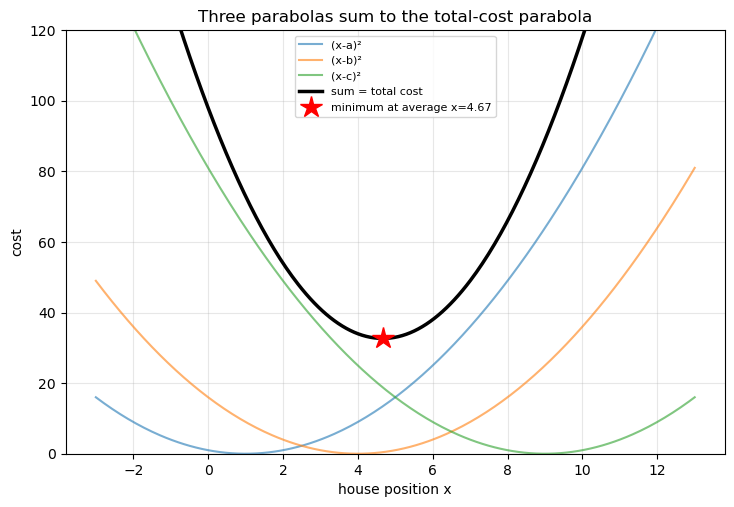

In [2]:
xs = np.linspace(-3, 13, 300)
plt.figure(figsize=(8.5, 5.5))
plt.plot(xs, (xs-a)**2, color="tab:blue", alpha=0.6, label="(x-a)²")
plt.plot(xs, (xs-b)**2, color="tab:orange", alpha=0.6, label="(x-b)²")
plt.plot(xs, (xs-c)**2, color="tab:green", alpha=0.6, label="(x-c)²")
plt.plot(xs, cost(xs), color="black", lw=2.5, label="sum = total cost")
plt.plot(avg, cost(avg), "r*", markersize=16, label=f"minimum at average x={avg:.2f}")
plt.title("Three parabolas sum to the total-cost parabola")
plt.xlabel("house position x"); plt.ylabel("cost")
plt.ylim(0, 120); plt.grid(True, alpha=0.3); plt.legend(fontsize=8)
plt.show()

## 3. Minimizing the cost

Differentiate (chain rule on each term) and set to zero:

$$
f'(x) = 2(x-a) + 2(x-b) + 2(x-c) = 0 .
$$

Divide by $2$ and reorganize:

$$
(x-a)+(x-b)+(x-c) = 0 \;\Rightarrow\; 3x - a - b - c = 0 \;\Rightarrow\; 3x = a+b+c,
$$

so

$$
\boxed{\;x = \frac{a+b+c}{3}.\;}
$$

The optimal house position is the **average** of the three power-line positions.

In [3]:
x, A, B, C = sp.symbols('x a b c')
f = (x - A)**2 + (x - B)**2 + (x - C)**2

fp = sp.diff(f, x)
print("f'(x) =", sp.expand(fp))                 # 6x - 2a - 2b - 2c
sol = sp.solve(fp, x)[0]
print("minimizing x =", sol)                     # (a + b + c)/3

print("for a=1, b=4, c=9: x =", sol.subs({A:1, B:4, C:9}), " (the average)")

f'(x) = -2*a - 2*b - 2*c + 6*x
minimizing x = a/3 + b/3 + c/3
for a=1, b=4, c=9: x = 14/3  (the average)


## 4. Generalizing: the square loss

For $n$ power lines at $a_1, a_2, \dots, a_n$, the same argument gives the optimum at the
**average**:

$$
f(x) = \sum_{i=1}^{n}(x - a_i)^2 \quad\Longrightarrow\quad x = \frac{1}{n}\sum_{i=1}^{n} a_i = \bar a .
$$

This $\sum (x - a_i)^2$ is the **square loss** (sum of squared errors) — one of the most
important loss functions in machine learning. It reappears later in the course for **linear
regression**.

In [4]:
# verify the n-line optimum is the average, for a random set of positions
rng = np.random.default_rng(0)
lines = rng.uniform(0, 20, size=7)

xs2 = sp.symbols('x')
total = sum((xs2 - p)**2 for p in lines)
opt = sp.solve(sp.diff(total, xs2), xs2)[0]
print("power lines:", np.round(lines, 2))
print(f"optimum (solve) = {float(opt):.4f}")
print(f"average         = {lines.mean():.4f}  -> match")

power lines:

 [12.74  5.4   0.82  0.33 16.27 18.26 12.13]
optimum (solve) = 9.4197
average         = 9.4197  -> match


### Areas balancing

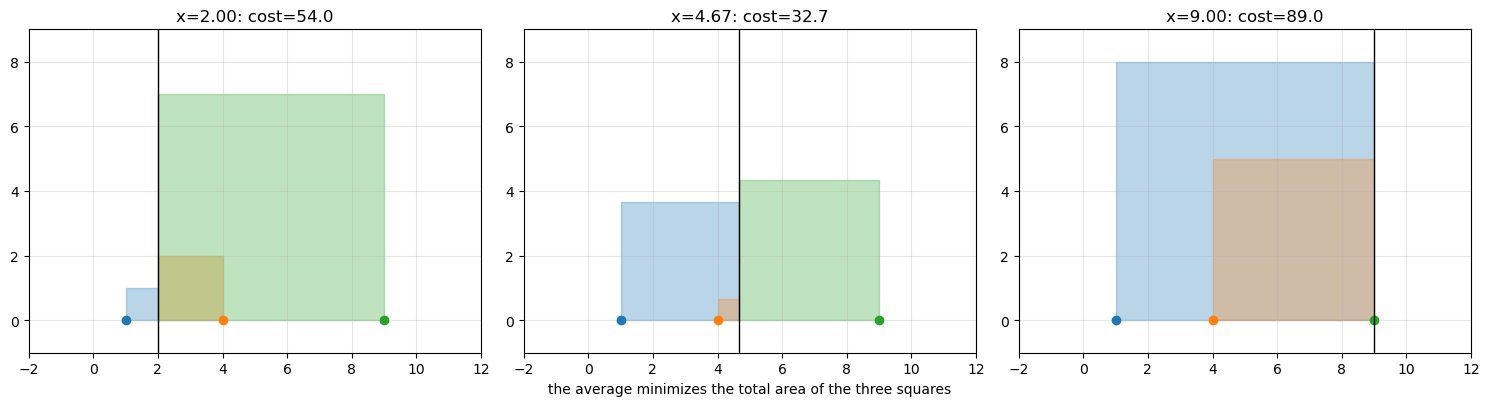

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, xpos in zip(axes, [2.0, avg, 9.0]):
    for p, col in [(a, "tab:blue"), (b, "tab:orange"), (c, "tab:green")]:
        d = abs(xpos - p)
        ax.add_patch(plt.Rectangle((xpos, 0), (p - xpos), d, alpha=0.3, color=col))
        ax.plot([p], [0], "o", color=col)
    ax.axvline(xpos, color="black", lw=1)
    ax.set_title(f"x={xpos:.2f}: cost={cost(xpos):.1f}")
    ax.set_xlim(-2, 12); ax.set_ylim(-1, 9); ax.set_aspect("equal"); ax.grid(True, alpha=0.3)
axes[1].set_xlabel("the average minimizes the total area of the three squares")
plt.tight_layout()
plt.show()

## 5. Exercises

### Basic
1. Write the cost function for three power lines at $a$, $b$, $c$.
2. Where should the house go for three power lines?

### Intermediate
3. For lines at $2$, $5$, $11$, find the optimal $x$ and the minimum cost.
4. Why does the far power line contribute the largest square?

### Advanced
5. Minimize $f(x) = (x-1)^2 + (x-4)^2 + (x-9)^2$ by hand using the derivative.
6. Show that for $n$ lines at $a_1, \dots, a_n$, the optimum is the average $\bar a$.

## 6. Solutions / Checks

In [6]:
x = sp.symbols('x')

# 3.
f3 = (x-2)**2 + (x-5)**2 + (x-11)**2
x3 = sp.solve(sp.diff(f3, x), x)[0]
print(f"3. optimal x = {x3} (= average {(2+5+11)/3:.3f}), min cost = {f3.subs(x, x3)}")

# 5.
f5 = (x-1)**2 + (x-4)**2 + (x-9)**2
print("5. f'(x) =", sp.expand(sp.diff(f5, x)), "-> x =", sp.solve(sp.diff(f5, x), x)[0])

# 6. n lines symbolic
a1, a2, a3, a4, a5 = sp.symbols('a1 a2 a3 a4 a5')
fn = sum((x - ai)**2 for ai in (a1, a2, a3, a4, a5))
print("6. optimum x =", sp.simplify(sp.solve(sp.diff(fn, x), x)[0]), " (the average)")

print("\n1. f(x) = (x-a)² + (x-b)² + (x-c)².")
print("2. The average x = (a+b+c)/3.")
print("4. Its distance is largest, and the square of a larger distance is larger.")

3. optimal x = 6 (= average 6.000), min cost = 42
5. f'(x) = 6*x - 28 -> x = 14/3
6. optimum x = a1/5 + a2/5 + a3/5 + a4/5 + a5/5  (the average)

1. f(x) = (x-a)² + (x-b)² + (x-c)².
2. The average x = (a+b+c)/3.
4. Its distance is largest, and the square of a larger distance is larger.


## 7. Conclusion

- For three power lines at $a, b, c$ the cost is
  $f(x) = (x-a)^2 + (x-b)^2 + (x-c)^2$, and minimizing it gives the **average**
  $x = \dfrac{a+b+c}{3}$.
- Geometrically, a parabola over each line sums to one parabola whose lowest point is that
  average — equivalently, the average balances the three square areas.
- This generalizes to $n$ lines (optimum = the average), and the objective
  $\sum (x - a_i)^2$ is the **square loss** — the foundation of least-squares and linear
  regression, which return later in the course.

## Appendix — Source transcript

Transcribed with OpenAI Whisper (`small.en`) from a locally downloaded video
(`~/Downloads/index (24).mp4`), the Coursera *Calculus for Machine Learning and Data
Science* (Week 1) lecture **optimization of squared loss — the three powerline problem**.
Key spoken points, lightly cleaned:

> Now there are three power lines, the third at distance $c$ from the origin. The distances
> are $x-a$, $x-b$, $x-c$ (signs don't matter since we square them). Drawing each as the area
> of a square, the far line gives the biggest square. The cost function is $(x-a)^2 + (x-b)^2
> + (x-c)^2$ — the total area — and the optimal $x$ is the average $(a+b+c)/3$. Geometrically,
> put the parabola $(x-a)^2$ over the blue line, $(x-b)^2$ over the orange, $(x-c)^2$ over the
> green; their heights sum to a black parabola whose minimum (zero-slope point) is the
> answer. The math: take the derivative, set it to zero, divide by 2, getting $3x - a - b - c
> = 0$, so $x = (a+b+c)/3$. Too far left or right gives big areas; the average is smallest.
> This generalizes to $n$ lines (the average of all coordinates) and is the square loss, a
> very important loss in machine learning that returns later.